
# Module 5 – Week 5: RC Circuit Modeling I (from Physics to Data)

**Course:** Research – Optimization with Calculus & Differential Equations  
**Focus:** Build the RC model from first principles, simulate non-constant inputs, and estimate parameters from (synthetic) data.

## Learning Goals
- Derive the RC ODE from **Kirchhoff’s laws** and the capacitor law $$ i_C = C\,\frac{dV_C}{dt} $$.  
- Simulate **non-constant inputs** (e.g., square waves) with numerical ODE solvers.  
- **Estimate the time constant** $ \tau=RC $ from data using basic curve fitting.  
- Interpret the meaning of $ \tau $ via rise/decay and the 10–90% rise time rule.



## ✅ Problems A & B

**Problem A — Parameter Estimation (Discharging data):**  
You are given voltage data from a discharging capacitor: $V_C(t)\approx V_0 e^{-t/\tau}$ plus small noise.  
1) Fit $ \tau $ from the data (use either linearization on $\ln V$ or `scipy.optimize.curve_fit`).  
2) Report $ \widehat{\tau} $, percent error vs. the true value, and show a plot with data vs. fitted curve.

**Problem B — Square-Wave Forcing (Periodic input):**  
The input $V_{in}(t)$ is a **square wave** with amplitude $V_0$, period $T$, and duty cycle $d$.  
1) Simulate the ODE $ \tau \frac{dV_C}{dt} + V_C = V_{in}(t) $ over several periods using `solve_ivp`.  
2) Plot $V_C(t)$ and discuss approach to steady state; compute the average $ \overline{V_C} $ over the last period.


## ✅ Submission Checklist
- [ ] Working code: simulation or fitting; printed key numbers ${\tau}$ or $ \overline{V_C} $.  
- [ ] At least **one plot** with labeled axes and units.  
- [ ] Reflection (3–5 sentences): what did $ \tau $ or duty cycle teach you about system behavior?  
- [ ] Notebook runs top-to-bottom without errors.




## A & B


tau_hat: 0.010110290800561746
tau_true: 0.01
Percent error in tau: 1.102908005617461 %
Percent error in V0: 0.4868246797929743 %


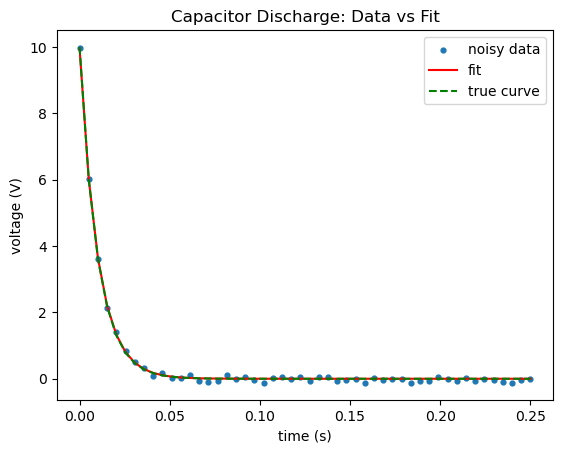

In [17]:
# A: Discharging data

# Import math
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Define variables
R_true = 10000
C_true = 1e-6
V0_true = 10
tau_true = R_true * C_true

# Create points of t
t_data = np.linspace(0, 0.25, 50)

# Clean
V_clean = V0_true*np.exp(-t_data/tau_true)

# Add noise
rng = np.random.default_rng(67)
V_noisy = V_clean + rng.normal(0, 0.067, size = t_data.size)

# Define function
def V_model(t, V0, tau):
    return V0 * np.exp(-t / tau)

# Guess
V0_guess = 9
tau_guess = 0.011
p0 = [V0_guess, tau_guess]

# Fit curve
popt, pcov = curve_fit(V_model, t_data, V_noisy, p0=p0, bounds=(0, np.inf))
V0_hat, tau_hat = popt

# Estimated tau & real tau
print("tau_hat:", tau_hat)
print("tau_true:", tau_true)

# Percent error
percent_error_tau = 100 * abs(tau_hat - tau_true) / tau_true
print("Percent error in tau:", percent_error_tau, "%")
percent_error_V0 = 100 * abs(V0_hat - V0_true) / V0_true
print("Percent error in V0:", percent_error_V0, "%")

plt.figure()
plt.scatter(t_data, V_noisy, s=12, label="noisy data")
plt.plot(t_data, V_model(t_data, V0_hat, tau_hat), color='red', label="fit")
plt.plot(t_data, V_clean, color='green', linestyle='--', label="true curve")
plt.xlabel("time (s)")
plt.ylabel("voltage (V)")
plt.title("Capacitor Discharge: Data vs Fit")
plt.legend()
plt.show()

Average Vc over last period ≈ 5.951815355212835


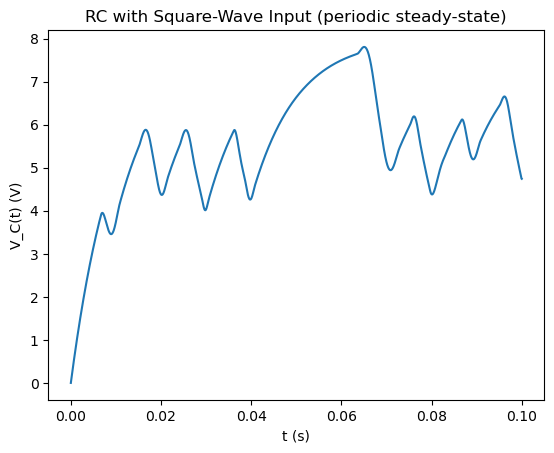

In [30]:

# B: Square Wave

# Import math
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Define variables
R = 10000
C = 1e-6
tau = R*C
V0 = 8.0
T = 0.01
duty = 0.67

# Define functions
def Vin(t):
    
    # Square wave
    phase = t % T
    return V0 if phase < duty*T else 0.0

def RC_ode(t, Vc):
    return (Vin(t) - Vc)/tau

# Time span and points
t_span = (0.0, 0.1)
t_eval = np.linspace(t_span[0], t_span[1], 2000)

# Solve
sol = solve_ivp(RC_ode, t_span, [0.0], t_eval=t_eval)

# Compute average over last period
mask = (t_eval >= (t_span[1] - T))
V_last = sol.y[0][mask]
t_last = t_eval[mask]
V_avg = np.trapezoid(V_last, t_last) / (t_last[-1]-t_last[0])

print("Average Vc over last period ≈", V_avg)

plt.figure()
plt.plot(t_eval, sol.y[0])
plt.xlabel("t (s)")
plt.ylabel("V_C(t) (V)")
plt.title("RC with Square-Wave Input (periodic steady-state)")
plt.show()
